In [16]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (4).csv


In [17]:
import pandas as pd

df = pd.read_csv('spam.csv' , encoding='latin-1')

In [18]:
# Getting rid of unnamed columns and renaming
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df.describe()

,label,text
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [19]:
# Getting rid of duplicates
print(df.isnull().sum())
df.drop_duplicates(inplace=True)

label    0
text     0
dtype: int64


In [20]:
# Encoding lavels: spam=1, ham=0
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

print(df.shape)
df.head()

(5169, 2)


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt

vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X = vectorizer.fit_transform(df['text'])
y = df['label']

# This is includes both splits and will be reused by both models

X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y)


In [22]:
# Logistic Regression (70/30)

lr_70_30 = LogisticRegression(max_iter=1000)
lr_70_30.fit(X_train_70, y_train_70)
y_pred_lr_70_30 = lr_70_30.predict(X_test_30)

print("--- Logistic Regression (70/30) ---")
print("Accuracy :", accuracy_score(y_test_30, y_pred_lr_70_30))
print("Precision:", precision_score(y_test_30, y_pred_lr_70_30))
print("Recall   :", recall_score(y_test_30, y_pred_lr_70_30))
print("F1 Score :", f1_score(y_test_30, y_pred_lr_70_30))

--- Logistic Regression (70/30) ---
Accuracy : 0.9458413926499033
Precision: 0.9912280701754386
Recall   : 0.576530612244898
F1 Score : 0.7290322580645161


In [23]:
# Naive Bayes (70/30)

nb_70_30 = MultinomialNB()
nb_70_30.fit(X_train_70, y_train_70)
y_pred_nb_70_30 = nb_70_30.predict(X_test_30)

print("--- Naive Bayes (70/30) ---")
print("Accuracy :", accuracy_score(y_test_30, y_pred_nb_70_30))
print("Precision:", precision_score(y_test_30, y_pred_nb_70_30))
print("Recall   :", recall_score(y_test_30, y_pred_nb_70_30))
print("F1 Score :", f1_score(y_test_30, y_pred_nb_70_30))

--- Naive Bayes (70/30) ---
Accuracy : 0.97678916827853
Precision: 0.9938271604938271
Recall   : 0.8214285714285714
F1 Score : 0.8994413407821229


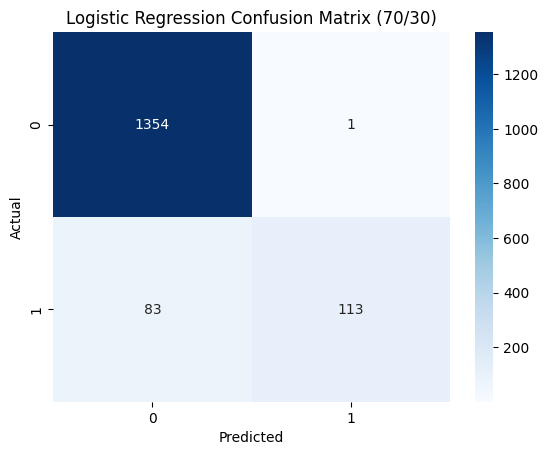

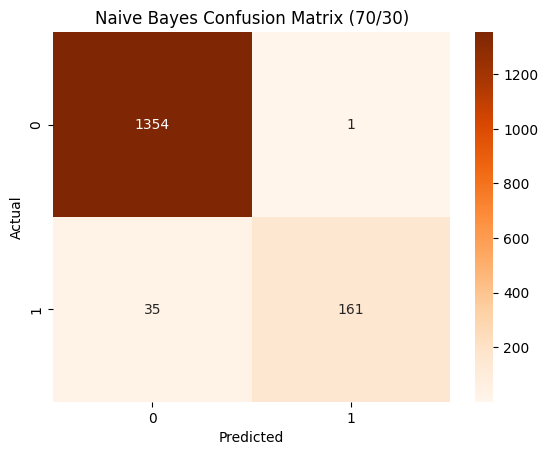

In [24]:
import seaborn as sns

# Logistic Regression (70/30) & Naive Bayes (70/30) Confusion Matrix

cm = confusion_matrix(y_test_30, y_pred_lr_70_30)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix (70/30)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

cm = confusion_matrix(y_test_30, y_pred_nb_70_30)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Naive Bayes Confusion Matrix (70/30)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

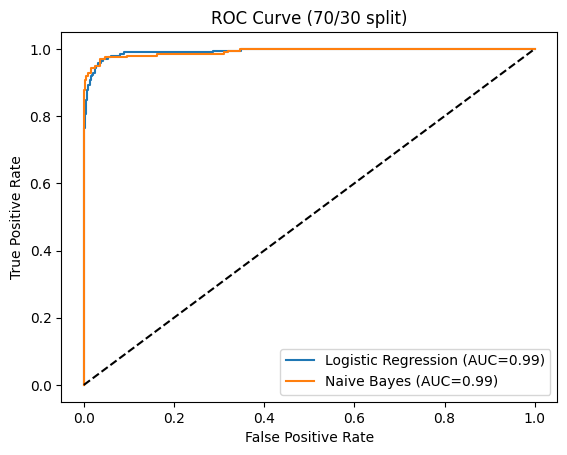

In [25]:
from sklearn.metrics import roc_curve, auc

# 70/30 ROC Curve, this will be both models on one plot
plt.figure()

# Logistic Regression
y_proba_lr = lr_70_30.predict_proba(X_test_30)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test_30, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc(fpr_lr, tpr_lr):.2f})')

# Naive Bayes
y_proba_nb = nb_70_30.predict_proba(X_test_30)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test_30, y_proba_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={auc(fpr_nb, tpr_nb):.2f})')

plt.plot([0,1], [0,1], 'k--')  # random guess baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (70/30 split)')
plt.legend()
plt.show()

In [26]:
# Logistic Regression (90/10)

lr_90_10 = LogisticRegression(max_iter=1000)
lr_90_10.fit(X_train_90, y_train_90)
y_pred_lr_90_10 = lr_90_10.predict(X_test_10)

print("--- Logistic Regression (90/10) ---")
print("Accuracy :", accuracy_score(y_test_10, y_pred_lr_90_10))
print("Precision:", precision_score(y_test_10, y_pred_lr_90_10))
print("Recall   :", recall_score(y_test_10, y_pred_lr_90_10))
print("F1 Score :", f1_score(y_test_10, y_pred_lr_90_10))

--- Logistic Regression (90/10) ---
Accuracy : 0.9632495164410058
Precision: 0.9791666666666666
Recall   : 0.7230769230769231
F1 Score : 0.831858407079646


In [27]:
# Naive Bayes (90/10)

nb_90_10 = MultinomialNB()
nb_90_10.fit(X_train_90, y_train_90)
y_pred_nb_90_10 = nb_90_10.predict(X_test_10)

print("--- Naive Bayes (90/10) ---")
print("Accuracy :", accuracy_score(y_test_10, y_pred_nb_90_10))
print("Precision:", precision_score(y_test_10, y_pred_nb_90_10))
print("Recall   :", recall_score(y_test_10, y_pred_nb_90_10))
print("F1 Score :", f1_score(y_test_10, y_pred_nb_90_10))

--- Naive Bayes (90/10) ---
Accuracy : 0.9825918762088974
Precision: 1.0
Recall   : 0.8615384615384616
F1 Score : 0.9256198347107438


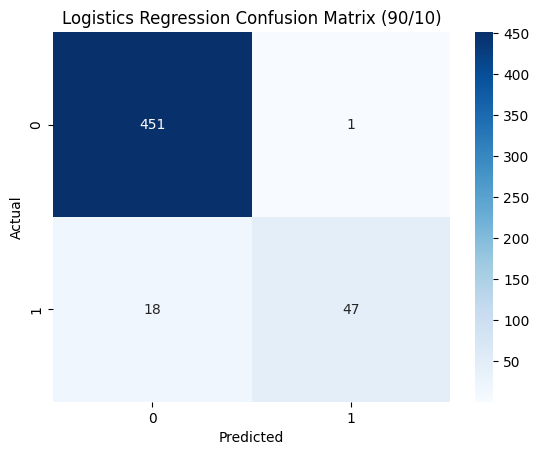

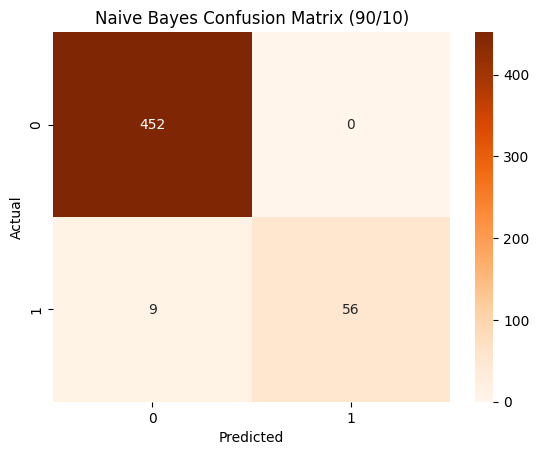

In [28]:
# Logistic Regression (90/10) & Naive Bayes (90/10) Confusion Matrix

cm = confusion_matrix(y_test_10, y_pred_lr_90_10)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistics Regression Confusion Matrix (90/10)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

cm = confusion_matrix(y_test_10, y_pred_nb_90_10)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Naive Bayes Confusion Matrix (90/10)')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

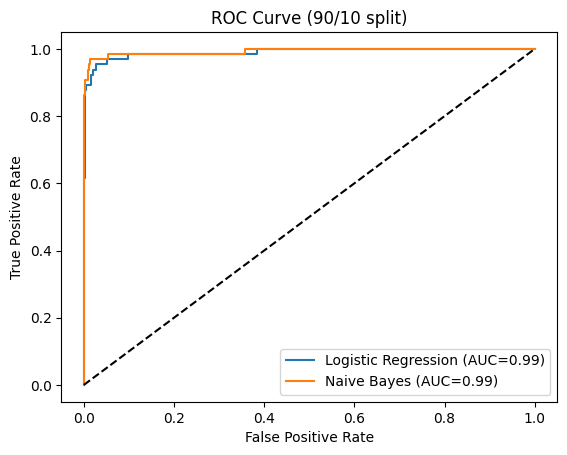

In [29]:
# 90/10 ROC Curve, this will be both models on one plot
plt.figure()

# Logistic Regression
y_proba_lr = lr_90_10.predict_proba(X_test_10)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test_10, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc(fpr_lr, tpr_lr):.2f})')

# Naive Bayes
y_proba_nb = nb_90_10.predict_proba(X_test_10)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test_10, y_proba_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={auc(fpr_nb, tpr_nb):.2f})')

plt.plot([0,1], [0,1], 'k--')  # random guess baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (90/10 split)')
plt.legend()
plt.show()